# Análise Exploratória de Dados - Dataset de Diabetes

Este notebook realiza a análise exploratória dos dados de diabetes.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os

# Configurações
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Conexão com PostgreSQL
POSTGRES_HOST = os.getenv('POSTGRES_HOST', 'postgres')
POSTGRES_PORT = os.getenv('POSTGRES_PORT', '5432')
POSTGRES_USER = os.getenv('POSTGRES_USER', 'postgres')
POSTGRES_PASSWORD = os.getenv('POSTGRES_PASSWORD', 'postgres')
POSTGRES_DB = os.getenv('POSTGRES_DB', 'diabetes_db')

DATABASE_URL = f"postgresql://{POSTGRES_USER}:{POSTGRES_PASSWORD}@{POSTGRES_HOST}:{POSTGRES_PORT}/{POSTGRES_DB}"
engine = create_engine(DATABASE_URL)

# Carregar dados
query = "SELECT * FROM diabetes_processed"
df = pd.read_sql(query, engine)

print(f"Dataset shape: {df.shape}")
print(f"\nPrimeiras linhas:")
df.head()


Dataset shape: (3000, 16)

Primeiras linhas:


,id,record_id,patient_number,gender,age,urea,creatinine,hba1c,cholesterol,triglycerides,hdl,ldl,vldl,bmi,class_label,created_at
0,1,502,17975,F,50,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N,2025-11-24 17:42:12.750321
1,2,735,34221,M,26,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N,2025-11-24 17:42:12.750321
2,3,420,47975,F,50,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N,2025-11-24 17:42:12.750321
3,4,680,87656,F,50,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N,2025-11-24 17:42:12.750321
4,5,504,34223,M,33,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N,2025-11-24 17:42:12.750321


In [2]:
# Informações gerais do dataset
print("=" * 60)
print("INFORMAÇÕES DO DATASET")
print("=" * 60)
print(f"\nShape: {df.shape}")
print(f"\nColunas: {list(df.columns)}")
print(f"\nTipos de dados:")
print(df.dtypes)
print(f"\nValores faltantes:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Nenhum valor faltante")
print(f"\nRegistros duplicados: {df.duplicated().sum()}")


INFORMAÇÕES DO DATASET

Shape: (3000, 16)

Colunas: ['id', 'record_id', 'patient_number', 'gender', 'age', 'urea', 'creatinine', 'hba1c', 'cholesterol', 'triglycerides', 'hdl', 'ldl', 'vldl', 'bmi', 'class_label', 'created_at']

Tipos de dados:
id                         int64
record_id                  int64
patient_number             int64
gender                    object
age                        int64
urea                     float64
creatinine               float64
hba1c                    float64
cholesterol              float64
triglycerides            float64
hdl                      float64
ldl                      float64
vldl                     float64
bmi                      float64
class_label               object
created_at        datetime64[ns]
dtype: object

Valores faltantes:
Nenhum valor faltante

Registros duplicados: 0


In [3]:
# Estatísticas descritivas
print("=" * 60)
print("ESTATÍSTICAS DESCRITIVAS")
print("=" * 60)
df.describe()


ESTATÍSTICAS DESCRITIVAS


,id,record_id,patient_number,age,urea,creatinine,hba1c,cholesterol,triglycerides,hdl,ldl,vldl,bmi,created_at
count,3000.000000,3000.0000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000
mean,1500.500000,340.5000,2.705514e+05,53.528000,5.124743,68.943000,8.281160,4.862820,2.349610,1.204750,2.60979,1.854700,29.578020,2025-11-24 18:12:59.499282688
min,1.000000,1.0000,1.230000e+02,20.000000,0.500000,6.000000,0.900000,0.000000,0.300000,0.200000,0.30000,0.100000,19.000000,2025-11-24 17:42:12.750321
25%,750.750000,125.7500,2.406375e+04,51.000000,3.700000,48.000000,6.500000,4.000000,1.500000,0.900000,1.80000,0.700000,26.000000,2025-11-24 17:42:12.750320896
50%,1500.500000,300.5000,3.439550e+04,55.000000,4.600000,60.000000,8.000000,4.800000,2.000000,1.100000,2.50000,0.900000,30.000000,2025-11-24 18:28:21.930170880
75%,2250.250000,550.2500,4.538425e+04,59.000000,5.700000,73.000000,10.200000,5.600000,2.900000,1.300000,3.30000,1.500000,33.000000,2025-11-24 18:28:23.817356032
max,3000.000000,800.0000,7.543566e+07,79.000000,38.900000,800.000000,16.000000,10.300000,13.800000,9.900000,9.90000,35.000000,47.750000,2025-11-24 18:28:23.817356
std,866.169729,240.3175,3.379630e+06,8.796306,2.934187,59.964742,2.533158,1.301303,1.400709,0.660193,1.11473,3.662377,4.960733,NaN


## Análise da Variável Target (CLASS)


DISTRIBUIÇÃO DAS CLASSES

Contagem:
class_label
N     309
P     159
Y    2532
Name: count, dtype: int64

Percentual:
  N: 309 (10.30%)
  P: 159 (5.30%)
  Y: 2532 (84.40%)


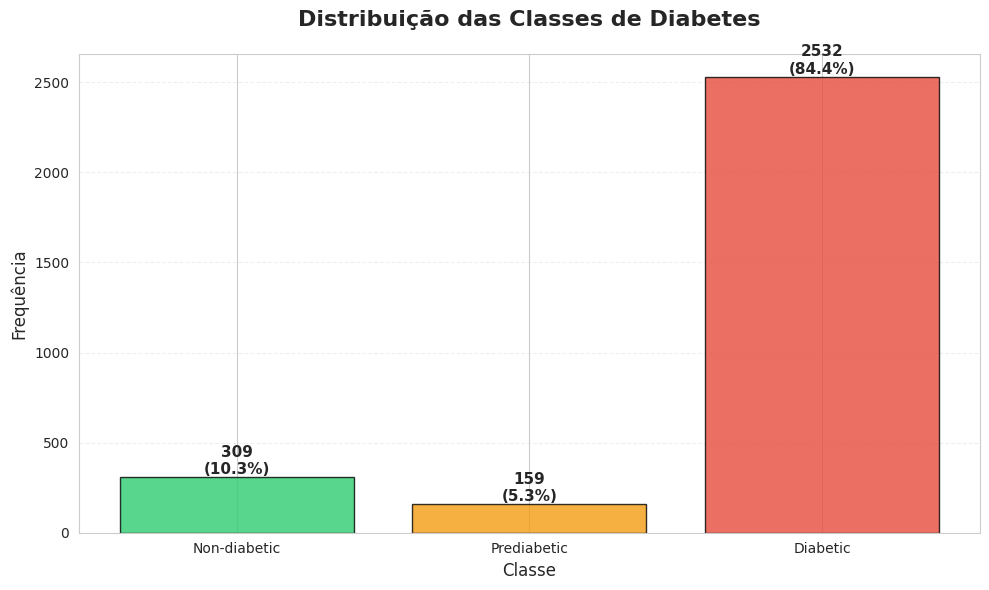

In [4]:
# Distribuição das classes
class_dist = df['class_label'].value_counts().sort_index()
class_percent = (df['class_label'].value_counts(normalize=True) * 100).sort_index()

print("=" * 60)
print("DISTRIBUIÇÃO DAS CLASSES")
print("=" * 60)
print("\nContagem:")
print(class_dist)
print("\nPercentual:")
for label, count in class_dist.items():
    pct = class_percent[label]
    print(f"  {label}: {count} ({pct:.2f}%)")

# Mapear labels para nomes
label_map = {'N': 'Non-diabetic', 'P': 'Prediabetic', 'Y': 'Diabetic'}
class_dist_named = class_dist.rename(index=label_map)

# Visualização
plt.figure(figsize=(10, 6))
colors = ['#2ecc71', '#f39c12', '#e74c3c']  # Verde, Laranja, Vermelho
bars = plt.bar(class_dist_named.index, class_dist_named.values, color=colors, alpha=0.8, edgecolor='black')
plt.title('Distribuição das Classes de Diabetes', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Classe', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.xticks(rotation=0)

# Adicionar valores nas barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}\n({height/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('../reports/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


## Análise por Gênero


DISTRIBUIÇÃO POR GÊNERO E CLASSE
class_label    N    P     Y   All
gender                           
F            192   51  1059  1302
M            117  108  1470  1695
f              0    0     3     3
All          309  159  2532  3000


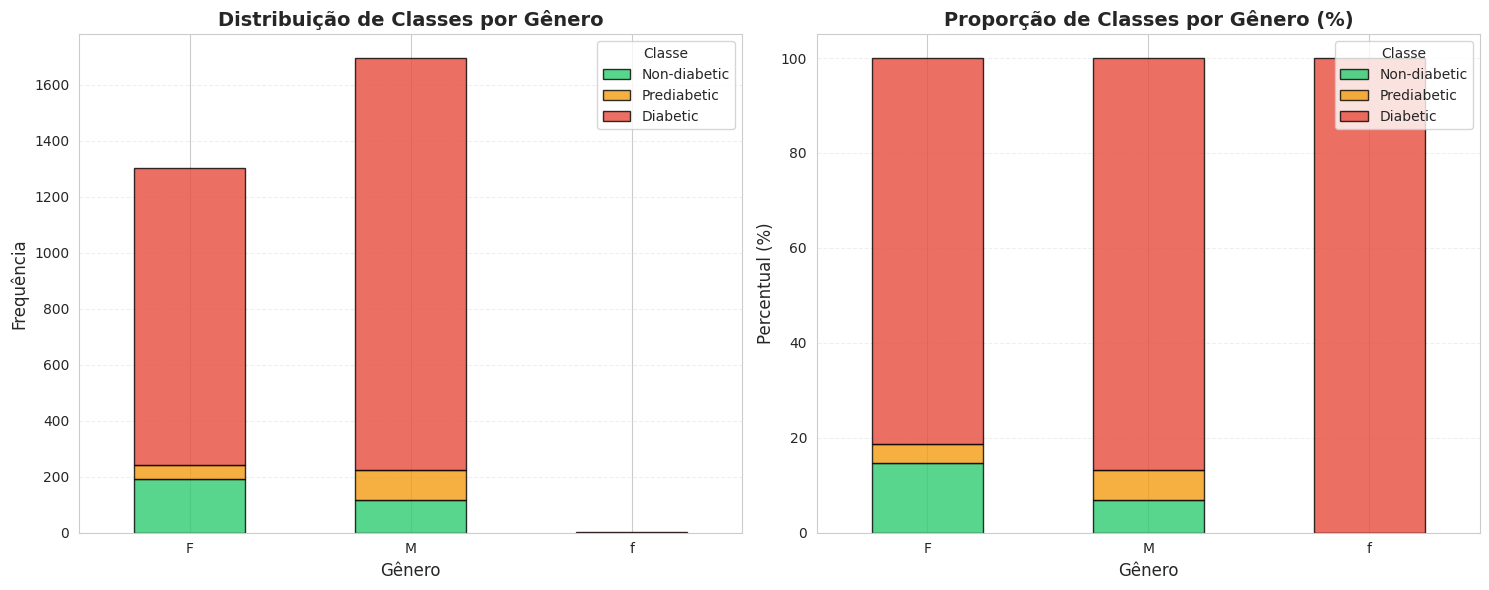

In [5]:
# Distribuição por gênero e classe
gender_class = pd.crosstab(df['gender'], df['class_label'], margins=True)
print("=" * 60)
print("DISTRIBUIÇÃO POR GÊNERO E CLASSE")
print("=" * 60)
print(gender_class)

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Stacked Bar
gender_class_plot = pd.crosstab(df['gender'], df['class_label'])
gender_class_plot_named = gender_class_plot.rename(columns=label_map)
gender_class_plot_named.plot(kind='bar', stacked=True, ax=axes[0], 
                             color=['#2ecc71', '#f39c12', '#e74c3c'], 
                             edgecolor='black', alpha=0.8)
axes[0].set_title('Distribuição de Classes por Gênero', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Gênero', fontsize=12)
axes[0].set_ylabel('Frequência', fontsize=12)
axes[0].legend(title='Classe', fontsize=10)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Gráfico 2: Proporções
gender_pct = pd.crosstab(df['gender'], df['class_label'], normalize='index') * 100
gender_pct_named = gender_pct.rename(columns=label_map)
gender_pct_named.plot(kind='bar', stacked=True, ax=axes[1], 
                      color=['#2ecc71', '#f39c12', '#e74c3c'], 
                      edgecolor='black', alpha=0.8)
axes[1].set_title('Proporção de Classes por Gênero (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Gênero', fontsize=12)
axes[1].set_ylabel('Percentual (%)', fontsize=12)
axes[1].legend(title='Classe', fontsize=10)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('../reports/gender_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


## Análise de Idade


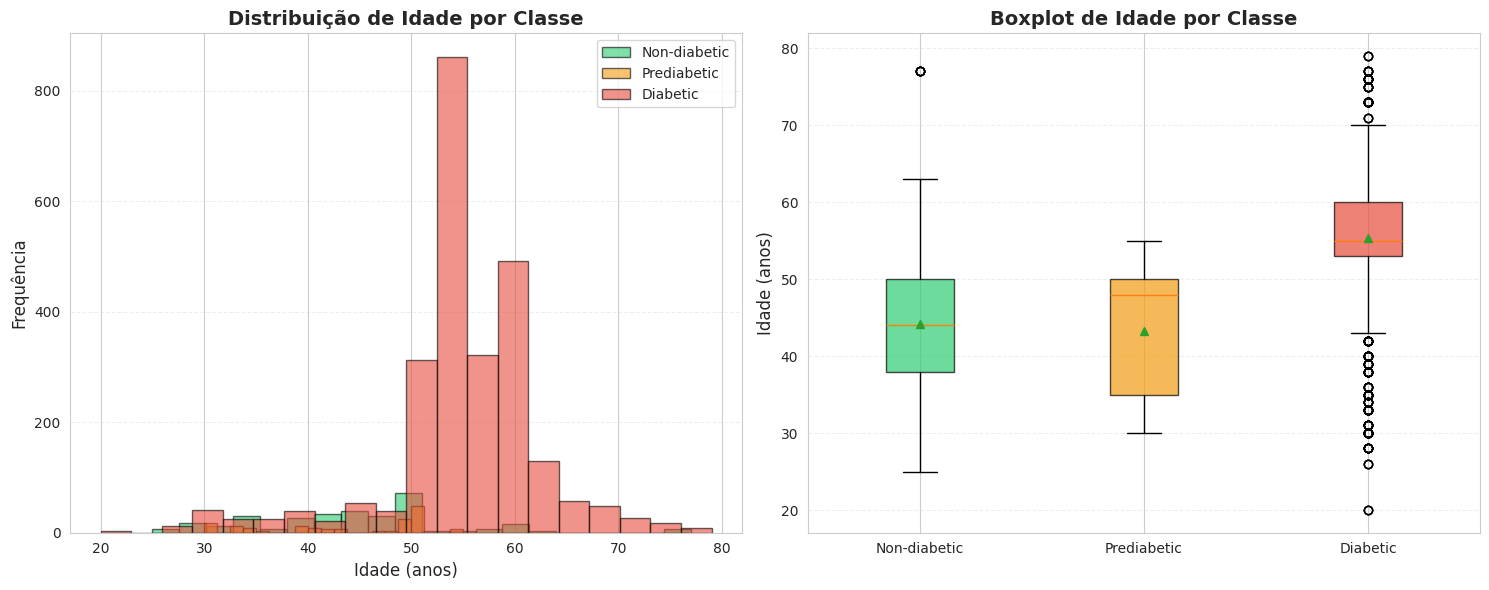

ESTATÍSTICAS DE IDADE POR CLASSE
              count       mean       std   min   25%   50%   75%   max
class_label                                                           
N             309.0  44.233010  9.387963  25.0  38.0  44.0  50.0  77.0
P             159.0  43.283019  7.712502  30.0  35.0  48.0  50.0  55.0
Y            2532.0  55.305687  7.545919  20.0  53.0  55.0  60.0  79.0


In [6]:
# Distribuição de idade por classe
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histograma
for class_label in sorted(df['class_label'].unique()):
    subset = df[df['class_label'] == class_label]
    label_name = label_map[class_label]
    color = {'N': '#2ecc71', 'P': '#f39c12', 'Y': '#e74c3c'}[class_label]
    axes[0].hist(subset['age'], alpha=0.6, label=label_name, bins=20, color=color, edgecolor='black')

axes[0].set_title('Distribuição de Idade por Classe', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Idade (anos)', fontsize=12)
axes[0].set_ylabel('Frequência', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Boxplot
df_boxplot = df.copy()
df_boxplot['class_label_named'] = df_boxplot['class_label'].map(label_map)
box_data = [df_boxplot[df_boxplot['class_label_named'] == name]['age'].values 
            for name in ['Non-diabetic', 'Prediabetic', 'Diabetic']]
bp = axes[1].boxplot(box_data, labels=['Non-diabetic', 'Prediabetic', 'Diabetic'],
                     patch_artist=True, showmeans=True)
colors_box = ['#2ecc71', '#f39c12', '#e74c3c']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_title('Boxplot de Idade por Classe', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Idade (anos)', fontsize=12)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('../reports/age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Estatísticas de idade por classe
print("=" * 60)
print("ESTATÍSTICAS DE IDADE POR CLASSE")
print("=" * 60)
print(df.groupby('class_label')['age'].describe())


## Matriz de Correlação


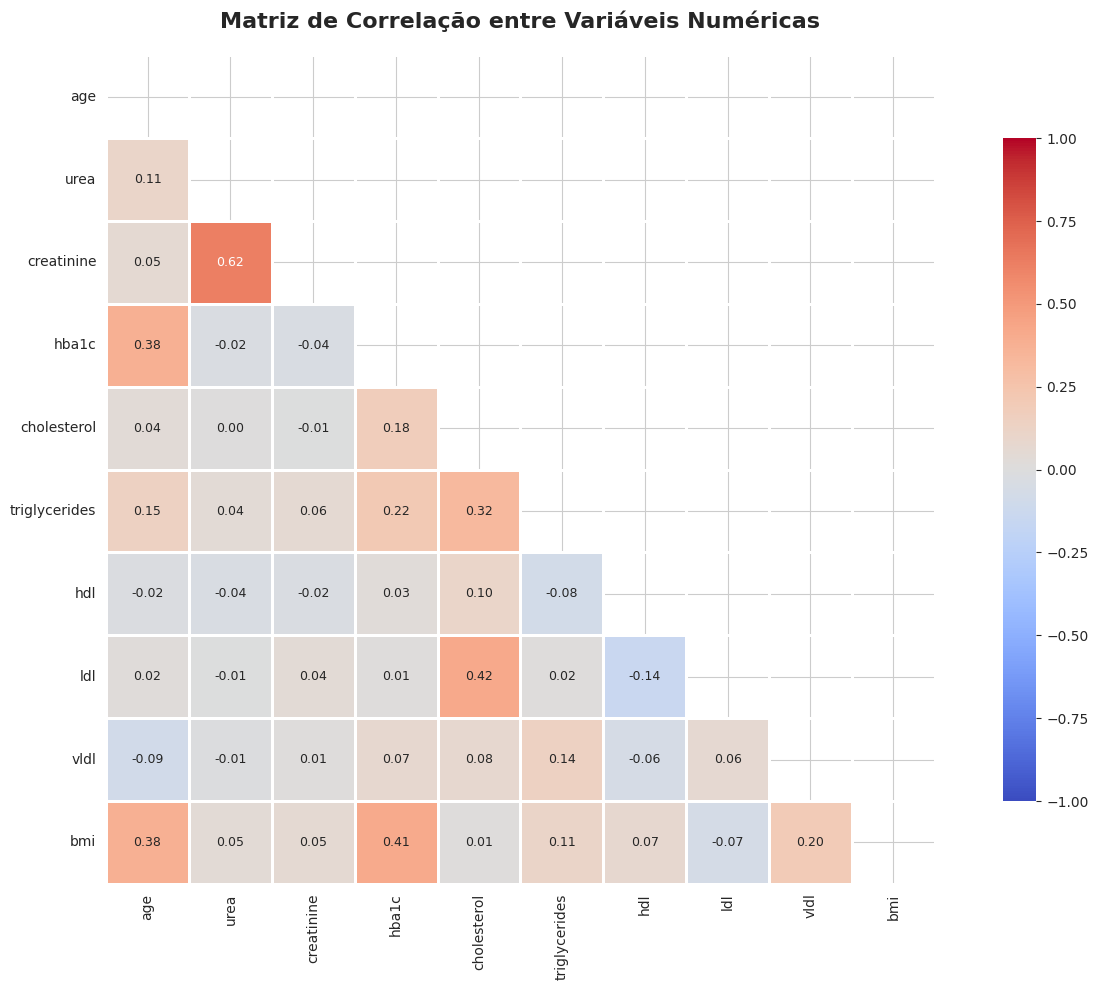

CORRELAÇÕES MAIS FORTES (abs > 0.3)
 Variável 1    Variável 2  Correlação
       urea    creatinine    0.624134
cholesterol           ldl    0.416665
      hba1c           bmi    0.413350
        age         hba1c    0.379136
        age           bmi    0.375956
cholesterol triglycerides    0.321789


In [7]:
# Selecionar apenas colunas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remover colunas de ID
numeric_cols = [col for col in numeric_cols if col not in ['id', 'record_id', 'patient_number']]

# Calcular correlação
correlation_matrix = df[numeric_cols].corr()

# Visualizar matriz de correlação
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Máscara para mostrar apenas triângulo inferior
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, annot_kws={'size': 9})
plt.title('Matriz de Correlação entre Variáveis Numéricas', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../reports/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Mostrar correlações mais fortes
print("=" * 60)
print("CORRELAÇÕES MAIS FORTES (abs > 0.3)")
print("=" * 60)
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.3:
            corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], corr_val))

corr_df = pd.DataFrame(corr_pairs, columns=['Variável 1', 'Variável 2', 'Correlação'])
corr_df = corr_df.sort_values('Correlação', key=abs, ascending=False)
print(corr_df.to_string(index=False))


## Análise de Variáveis Biomédicas Importantes


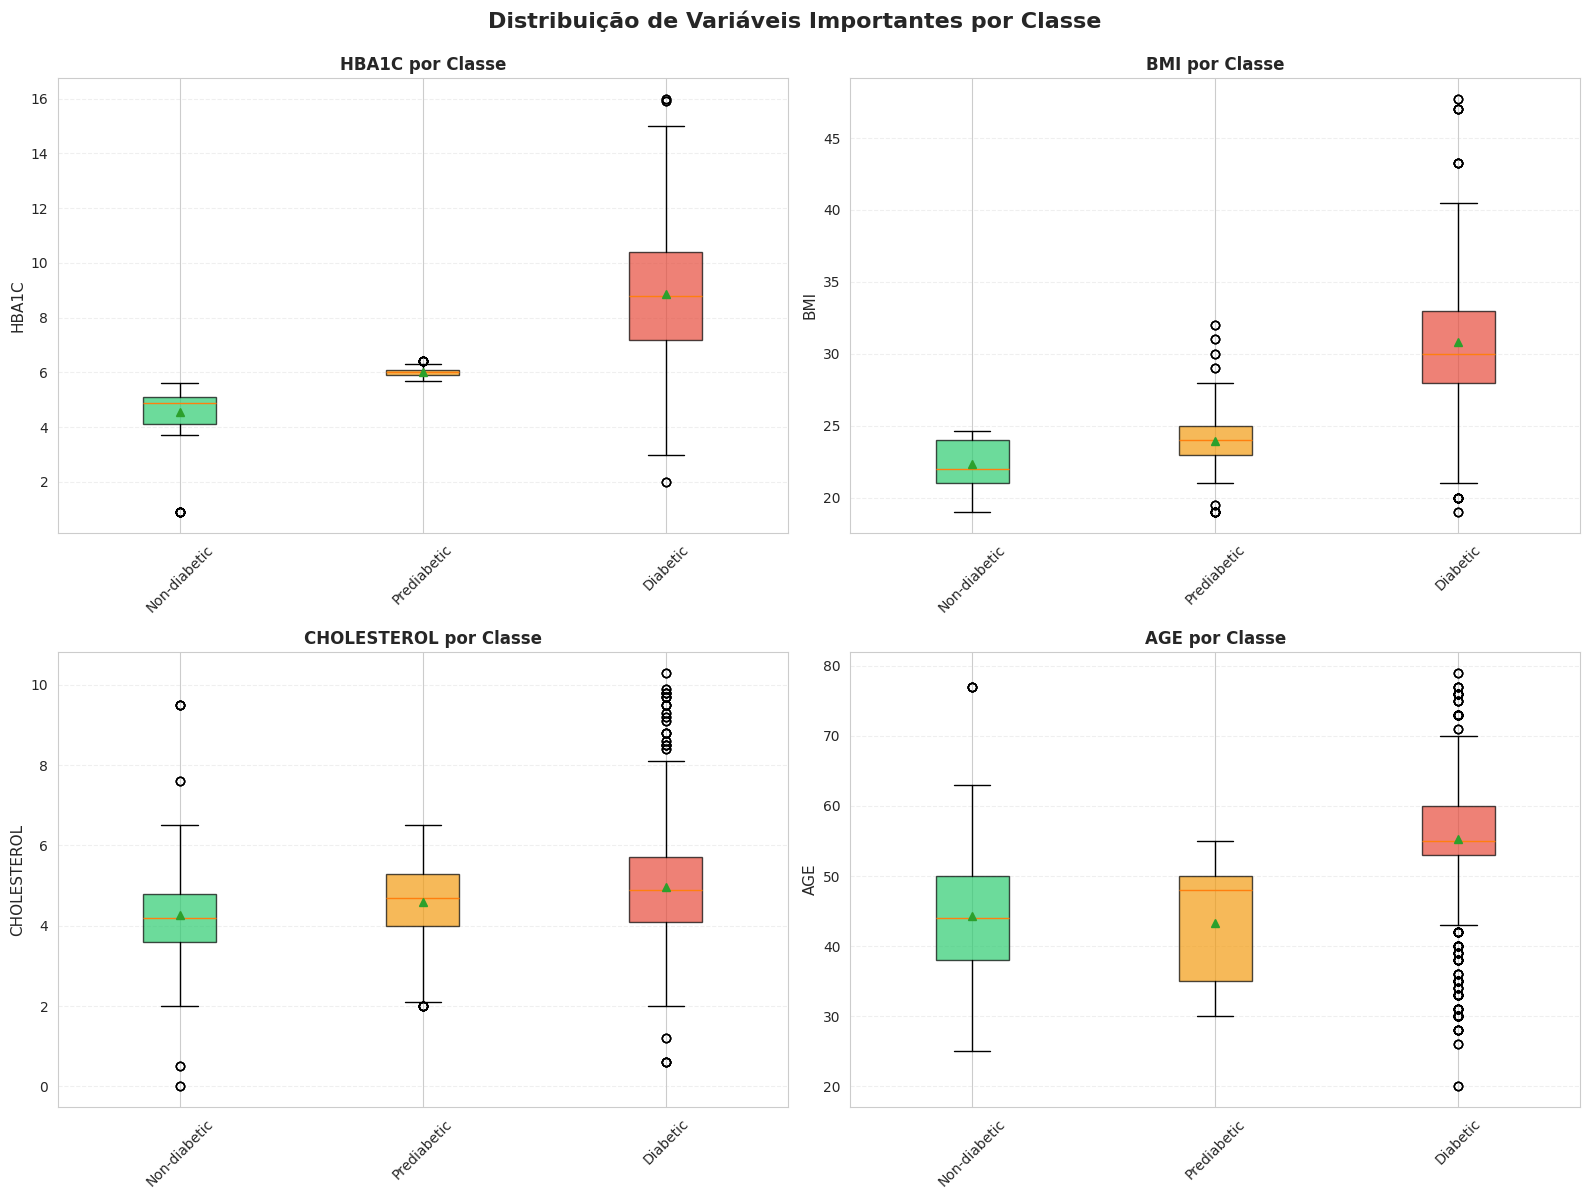

In [8]:
# Variáveis importantes para diabetes
important_vars = ['hba1c', 'bmi', 'cholesterol', 'age', 'glucose' if 'glucose' in df.columns else None]
important_vars = [v for v in important_vars if v is not None and v in df.columns]

if len(important_vars) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.ravel()
    
    for idx, var in enumerate(important_vars[:4]):  # Limitar a 4 variáveis
        df_boxplot = df.copy()
        df_boxplot['class_label_named'] = df_boxplot['class_label'].map(label_map)
        
        box_data = [df_boxplot[df_boxplot['class_label_named'] == name][var].values 
                    for name in ['Non-diabetic', 'Prediabetic', 'Diabetic']]
        bp = axes[idx].boxplot(box_data, labels=['Non-diabetic', 'Prediabetic', 'Diabetic'],
                               patch_artist=True, showmeans=True)
        
        colors_box = ['#2ecc71', '#f39c12', '#e74c3c']
        for patch, color in zip(bp['boxes'], colors_box):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        axes[idx].set_title(f'{var.upper()} por Classe', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel(var.upper(), fontsize=11)
        axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
        axes[idx].tick_params(axis='x', rotation=45)
    
    plt.suptitle('Distribuição de Variáveis Importantes por Classe', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig('../reports/boxplots_by_class.png', dpi=300, bbox_inches='tight')
    plt.show()


## Análise de HbA1c (Glicohemoglobina)

A HbA1c é uma das variáveis mais importantes para diagnóstico de diabetes.


/tmp/ipykernel_704/251286781.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_violin, x='class_label_named', y='hba1c',


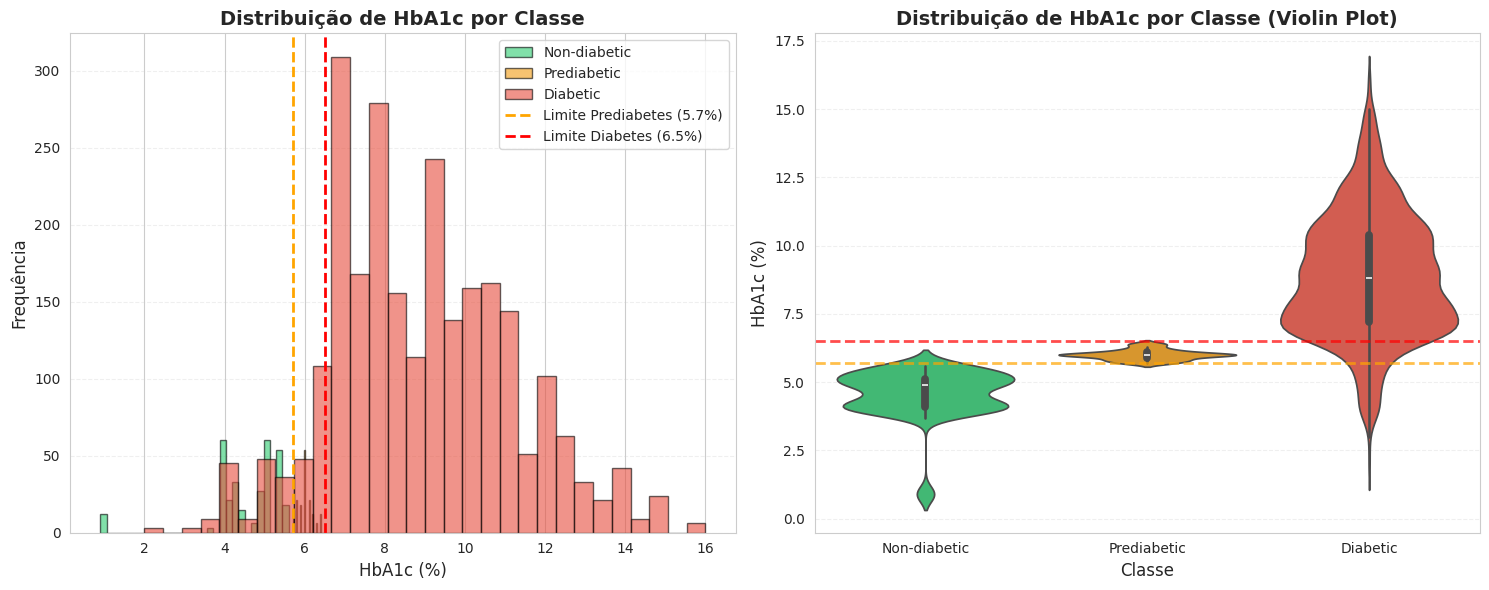

ESTATÍSTICAS DE HbA1c POR CLASSE
              count      mean       std  min  25%  50%   75%   max
class_label                                                       
N             309.0  4.560194  0.919204  0.9  4.1  4.9   5.1   5.6
P             159.0  6.003774  0.186875  5.7  5.9  6.0   6.1   6.4
Y            2532.0  8.878270  2.263970  2.0  7.2  8.8  10.4  16.0


In [9]:
# Análise detalhada de HbA1c
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histograma
for class_label in sorted(df['class_label'].unique()):
    subset = df[df['class_label'] == class_label]
    label_name = label_map[class_label]
    color = {'N': '#2ecc71', 'P': '#f39c12', 'Y': '#e74c3c'}[class_label]
    axes[0].hist(subset['hba1c'], alpha=0.6, label=label_name, bins=30, color=color, edgecolor='black')

axes[0].axvline(x=5.7, color='orange', linestyle='--', linewidth=2, label='Limite Prediabetes (5.7%)')
axes[0].axvline(x=6.5, color='red', linestyle='--', linewidth=2, label='Limite Diabetes (6.5%)')
axes[0].set_title('Distribuição de HbA1c por Classe', fontsize=14, fontweight='bold')
axes[0].set_xlabel('HbA1c (%)', fontsize=12)
axes[0].set_ylabel('Frequência', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Violin plot
df_violin = df.copy()
df_violin['class_label_named'] = df_violin['class_label'].map(label_map)
sns.violinplot(data=df_violin, x='class_label_named', y='hba1c', 
               order=['Non-diabetic', 'Prediabetic', 'Diabetic'],
               palette=['#2ecc71', '#f39c12', '#e74c3c'], ax=axes[1])
axes[1].axhline(y=5.7, color='orange', linestyle='--', linewidth=2, alpha=0.7)
axes[1].axhline(y=6.5, color='red', linestyle='--', linewidth=2, alpha=0.7)
axes[1].set_title('Distribuição de HbA1c por Classe (Violin Plot)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Classe', fontsize=12)
axes[1].set_ylabel('HbA1c (%)', fontsize=12)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('../reports/hba1c_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Estatísticas de HbA1c por classe
print("=" * 60)
print("ESTATÍSTICAS DE HbA1c POR CLASSE")
print("=" * 60)
print(df.groupby('class_label')['hba1c'].describe())


## Conclusões da Análise Exploratória

### Principais Achados:

1. **Distribuição de Classes**: 
   - O dataset apresenta distribuição [preencher após análise]

2. **Variáveis Mais Importantes**:
   - HbA1c é a variável mais correlacionada com diabetes
   - [Adicionar outras observações]

3. **Padrões Identificados**:
   - [Adicionar padrões encontrados]

4. **Próximos Passos**:
   - Pré-processamento dos dados
   - Balanceamento de classes (se necessário)
   - Treinamento de modelos de classificação
